In [1]:
%autosave 120

Autosaving every 120 seconds


# 4. Evaluation Metrics for Classification

In the previous session we trained a model for predicting churn. How do we know if it's good?


## 4.1 Evaluation metrics: session overview 

* Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
* https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv


*Metric* - function that compares the predictions with the actual values and outputs a single number that tells how good the predictions are

In [2]:
# %pip install pandas numpy matplotlib scikit-learn

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [4]:
np.set_printoptions(legacy='1.25')

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [6]:
df = pd.read_csv('data-week-3.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.5,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,yes


In [7]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

In [8]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                   str
dtype: object

In [9]:
df.churn = (df.churn == 'yes').astype(int)

In [10]:
df.churn.value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [11]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [12]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [13]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [14]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

0.801277501774308

## 4.2 Accuracy and dummy model

* Evaluate the model on different thresholds
* Check the accuracy of dummy baselines

In [15]:
len(y_val)

1409

In [16]:
(y_val == churn_decision).sum()

1129

In [17]:
(y_val == churn_decision).mean()

0.801277501774308

In [18]:
1129/ 1409

0.801277501774308

In [19]:
from sklearn.metrics import accuracy_score

In [20]:
accuracy_score(y_val, y_pred >= 0.5)

0.801277501774308

In [21]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.274
0.05 0.509
0.10 0.598
0.15 0.664
0.20 0.707
0.25 0.737
0.30 0.759
0.35 0.766
0.40 0.780
0.45 0.793
0.50 0.801
0.55 0.798
0.60 0.797
0.65 0.784
0.70 0.765
0.75 0.744
0.80 0.730
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


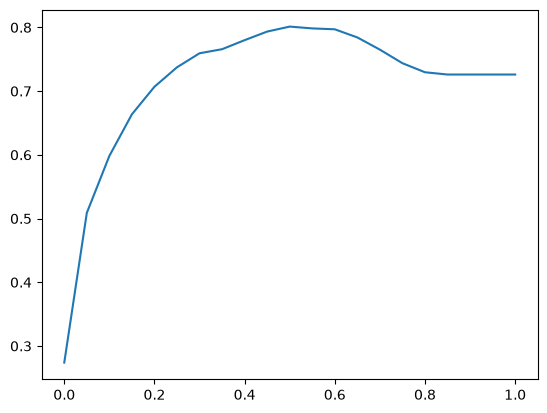

In [22]:
plt.plot(thresholds, scores)

In [23]:
y_pred >= 1.0

array([False, False, False, ..., False, False, False])

In [24]:
from collections import Counter

In [25]:
Counter(y_pred >= 1.0)

Counter({False: 1409})

In [26]:
Counter(y_val)      # 72.6% non-churn / 27.3% churn   # accuracy is misleading for the case of class imbalance in dataset

Counter({0: 1023, 1: 386})

In [27]:
y_val.mean()         # 27.3% customers are churning

0.2739531582682754

In [28]:
1 - y_val.mean()    # 72.6% customers are non-churning

0.7260468417317246

## 4.3 Confusion table

* Different types of errors and correct decisions
* Arranging them in a table

In [29]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [30]:
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

In [31]:
tp = (predict_positive & actual_positive).sum()     # 214
tn = (predict_negative & actual_negative).sum()     # 915

fp = (predict_positive & actual_negative).sum()     # 108
fn = (predict_negative & actual_positive).sum()     # 172

In [32]:
(tp, tn)

(214, 915)

In [33]:
(fp, fn)

(108, 172)

In [34]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix

array([[915, 108],
       [172, 214]])

In [35]:
(confusion_matrix / confusion_matrix.sum()).round(3)

array([[0.649, 0.077],
       [0.122, 0.152]])

## 4.4 Precision and Recall

In [36]:
# Pecision - Fraction of positive predictions are correct 
p = tp / (tp + fp)
p

0.6645962732919255

In [37]:
# Recall - Fraction of real positive which are predicted correctly
r = tp / (tp + fn)
r

0.5544041450777202

## 4.5 Receiver Operating Characteristic (ROC Curves)

### True Positive Rate (TPR) and False Positive Rate (FPR)

In [38]:
# TPR same as Recall
tpr = tp / (tp + fn)
tpr

0.5544041450777202

In [39]:
fpr = fp / (fp + tn)
fpr

0.10557184750733138

In [40]:
thresholds = np.linspace(0, 1, 101)

scores = []

for t in thresholds:

    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()     
    tn = (predict_negative & actual_negative).sum()     

    fp = (predict_positive & actual_negative).sum()     
    fn = (predict_negative & actual_positive).sum()     

    scores.append((t, tp, fp, fn, tn))   # list of tuples

In [41]:
scores

[(0.0, 386, 1023, 0, 0),
 (0.01, 385, 903, 1, 120),
 (0.02, 384, 812, 2, 211),
 (0.03, 382, 753, 4, 270),
 (0.04, 380, 708, 6, 315),
 (0.05, 378, 684, 8, 339),
 (0.06, 376, 660, 10, 363),
 (0.07, 374, 631, 12, 392),
 (0.08, 371, 601, 15, 422),
 (0.09, 369, 569, 17, 454),
 (0.1, 367, 547, 19, 476),
 (0.11, 365, 520, 21, 503),
 (0.12, 363, 503, 23, 520),
 (0.13, 362, 481, 24, 542),
 (0.14, 357, 454, 29, 569),
 (0.15, 351, 439, 35, 584),
 (0.16, 348, 420, 38, 603),
 (0.17, 346, 399, 40, 624),
 (0.18, 345, 390, 41, 633),
 (0.19, 340, 372, 46, 651),
 (0.2, 334, 361, 52, 662),
 (0.21, 329, 350, 57, 673),
 (0.22, 327, 334, 59, 689),
 (0.23, 321, 318, 65, 705),
 (0.24, 317, 309, 69, 714),
 (0.25, 314, 298, 72, 725),
 (0.26, 310, 282, 76, 741),
 (0.27, 307, 271, 79, 752),
 (0.28, 301, 265, 85, 758),
 (0.29, 294, 252, 92, 771),
 (0.3, 291, 244, 95, 779),
 (0.31, 283, 237, 103, 786),
 (0.32, 282, 230, 104, 793),
 (0.33, 277, 227, 109, 796),
 (0.34, 273, 220, 113, 803),
 (0.35000000000000003, 271,

In [42]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [43]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, fp, fn, tn))

In [44]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [45]:
df_scores[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,367,547,19,476,0.950777,0.534702
20,0.2,334,361,52,662,0.865285,0.352884
30,0.3,291,244,95,779,0.753886,0.238514
40,0.4,253,177,133,846,0.655440,0.173021
50,0.5,214,108,172,915,0.554404,0.105572
60,0.6,153,53,233,970,0.396373,0.051808
70,0.7,69,14,317,1009,0.178756,0.013685
80,0.8,5,0,381,1023,0.012953,0.000000
90,0.9,0,0,386,1023,0.000000,0.000000


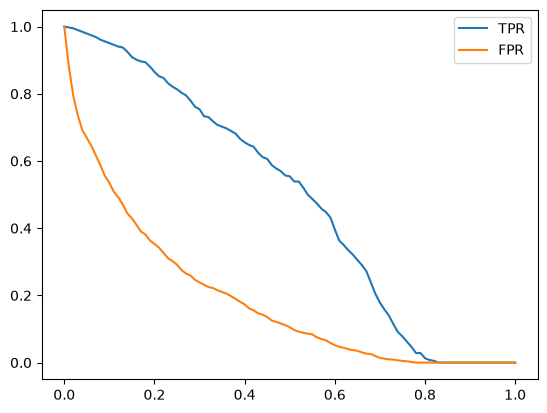

In [46]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.legend()

### Random model

In [47]:
# Assign the customers with a random score between 0 and 1
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))

In [48]:
y_rand.round(3)

array([0.417, 0.72 , 0.   , ..., 0.774, 0.334, 0.089])

In [49]:
rm_accuracy = ((y_rand >= 0.5) == y_val).mean()
rm_accuracy

0.5017743080198722

In [50]:
def tpr_fpr_dataframe(y_val, y_pred):

    thresholds = np.linspace(0, 1, 101)

    scores = []

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
    
    return df_scores

In [51]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)

In [52]:
df_rand[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,347,923,39,100,0.898964,0.902248
20,0.2,307,822,79,201,0.795337,0.803519
30,0.3,276,724,110,299,0.715026,0.707722
40,0.4,237,624,149,399,0.613990,0.609971
50,0.5,202,518,184,505,0.523316,0.506354
60,0.6,161,409,225,614,0.417098,0.399804
70,0.7,121,302,265,721,0.313472,0.295210
80,0.8,78,206,308,817,0.202073,0.201369
90,0.9,40,101,346,922,0.103627,0.098729


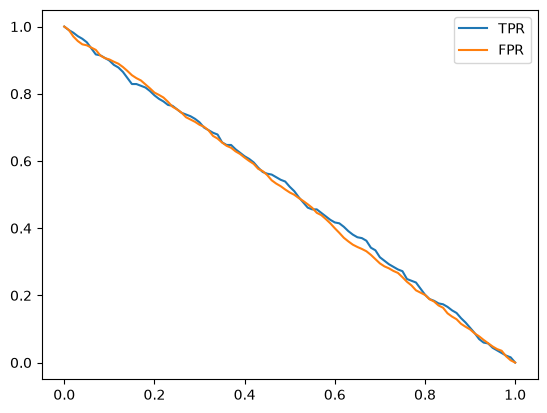

In [53]:
plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')
plt.legend()

### Ideal model

```text
|--------------------------------------------------------------|
0                                                            1409

                                       0.726
                                        ↓
<---------------- 1023 ----------------><------ 386 -------->  
           NON-CHURNERS                         CHURNERS
```

In [54]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()
num_neg, num_pos

(1023, 386)

In [55]:
# Sort the customers so all 1023 negatives (non-churner) come first, then all 386 positives (churner), and give them scores evenly spread from 0 to 1
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1])

In [56]:
y_ideal_pred = np.linspace(0, 1, len(y_val))  # gives scores gradually increasing from 0 to 1
y_ideal_pred

array([0.00000000e+00, 7.10227273e-04, 1.42045455e-03, ...,
       9.98579545e-01, 9.99289773e-01, 1.00000000e+00])

In [57]:
# y_val.mean() is the proportion of 1 (churn) 
1 - y_val.mean()     # 72.6% of validation customers are non-churners.

0.7260468417317246

In [58]:
im_accuracy = ((y_ideal_pred >=0.726) == y_ideal).mean()
im_accuracy

1.0

In [59]:
accuracy_score(y_ideal, y_ideal_pred >= 0.726)

1.0

In [60]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


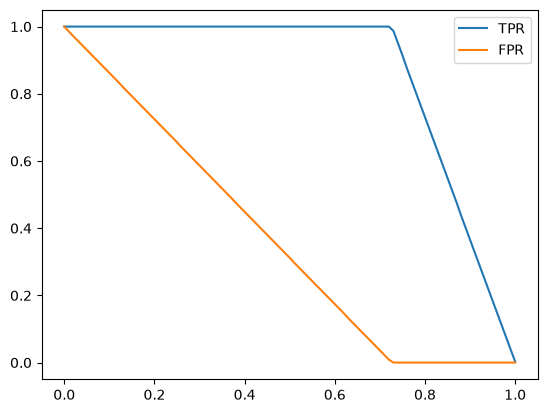

In [61]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR')
plt.legend()

### Putting everything together

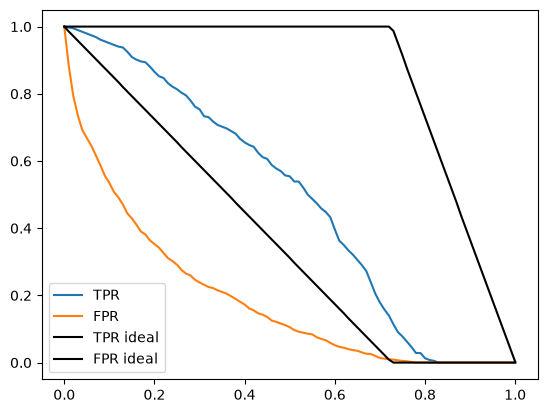

In [90]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')

plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR ideal', color='black')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR ideal', color='black')

# plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR random', color='grey')
# plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR random', color='grey')

plt.legend()

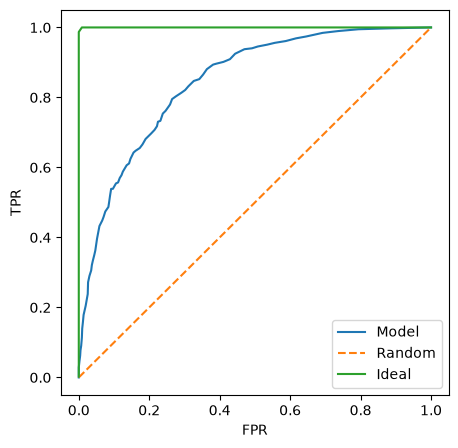

In [96]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')
# plt.plot(df_rand.fpr, df_rand.tpr, label='Random')
plt.plot(df_ideal.fpr, df_ideal.tpr, label='Ideal')  # when TRP is 100%, FPR is 0% 

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

ROC curves with scikit-learn

In [64]:
from sklearn.metrics import roc_curve

`roc_curve` from scikit-learn does it in one call, returning the false positive rates, the true positive rates and the thresholds

In [65]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

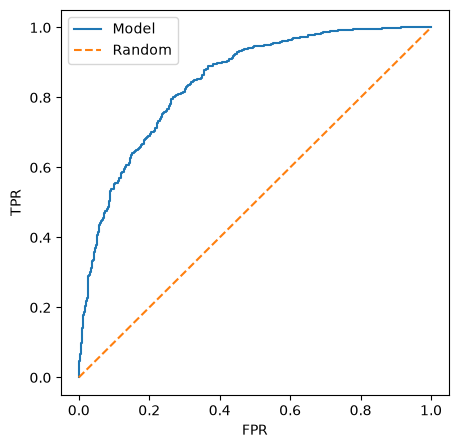

In [66]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

## 4.6 ROC AUC

* Area under the ROC curve - useful metric
* Interpretation of AUC

In [67]:
from sklearn.metrics import auc

In [68]:
auc(fpr, tpr)

0.8445038720820102

In [69]:
auc(df_scores.fpr, df_scores.tpr)

0.8443696534119398

In [70]:
auc(df_ideal.fpr, df_ideal.tpr)

0.9999430203759136

In [71]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr)

0.8445038720820102

In [72]:
from sklearn.metrics import roc_auc_score

In [73]:
roc_auc_score(y_val, y_pred)

0.8445038720820102

In [74]:
neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [75]:
import random

In [76]:
n = 100000
success = 0 

for i in range(n):
    pos_ind = random.randint(0, len(pos) - 1)
    neg_ind = random.randint(0, len(neg) - 1)

    if pos[pos_ind] > neg[neg_ind]:
        success = success + 1

success / n

0.84472

In [99]:
n = 50000

np.random.seed(1)
pos_ind = np.random.randint(0, len(pos), size=n)
neg_ind = np.random.randint(0, len(neg), size=n)

(pos[pos_ind] > neg[neg_ind]).mean()

0.8466

## 4.7 Cross-Validation

* Evaluating the same model on different subsets of data
* Getting the average prediction and the spread within predictions

In [187]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')  
  
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='lbfgs', C=C, max_iter=5000)
    model.fit(X_train, y_train)
    
    return dv, model

In [188]:
dv, model = train(df_train, y_train, C=0.001)

In [189]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')    # convert data frame into list of dictionaries

    X = dv.transform(dicts)                    # create feature matrix using DictVectorizer
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [190]:
y_pred = predict(df_val, dv, model)

In [191]:
from sklearn.model_selection import KFold

In [192]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

In [193]:
# train_idx, val_idx = next(kfold.split(df_full_train))
# train_idx
# val_idx

In [194]:
len(train_idx), len(val_idx), len(df_full_train)

(4508, 1126, 5634)

In [195]:
!pip install tqdm

In [196]:
from tqdm.auto import tqdm

In [197]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):    # C is regularization
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

 14%|█████████████████▌                                                                                                         | 1/7 [00:01<00:11,  1.98s/it]

C=0.001 0.825 +- 0.009


 29%|███████████████████████████████████▏                                                                                       | 2/7 [00:06<00:17,  3.53s/it]

C=0.01 0.840 +- 0.008


 43%|████████████████████████████████████████████████████▋                                                                      | 3/7 [00:15<00:23,  5.87s/it]

C=0.1 0.842 +- 0.007


 57%|██████████████████████████████████████████████████████████████████████▎                                                    | 4/7 [00:21<00:17,  6.00s/it]

C=0.5 0.842 +- 0.007


 71%|███████████████████████████████████████████████████████████████████████████████████████▊                                   | 5/7 [00:27<00:12,  6.03s/it]

C=1 0.842 +- 0.007


 86%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▍                 | 6/7 [00:33<00:06,  6.04s/it]

C=5 0.842 +- 0.007


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:39<00:00,  5.61s/it]

C=10 0.842 +- 0.007


In [201]:
scores

[0.8439646442841331,
 0.8448115315852205,
 0.833694561509131,
 0.8348128637206625,
 0.8516441278905589]

In [199]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8584032088573997

## 4.8 Summary

* Metric - a single number that describes the performance of a model
* Accuracy - fraction of correct answers; sometimes misleading 
* Precision and recall are less misleading when we have class inbalance
* ROC Curve - a way to evaluate the performance at all thresholds; okay to use with imbalance
* K-Fold CV - more reliable estimate for performance (mean + std)

```text
                 YOUR CUSTOMER DATA
                         │
                         ▼
                 ┌──────────────┐
                 │ ML MODEL     │
                 └──────────────┘
                         │
                         ▼
              CHURN PROBABILITY/SCORE
                  e.g. 0.82
                  e.g. 0.43
                  e.g. 0.17
                         │
                         ▼
                 CHOOSE THRESHOLD
                    e.g. 0.70
                         │
              ┌──────────┴──────────┐
              │                     │
           score ≥ .70          score < .70
              │                     │
              ▼                     ▼
          PREDICT CHURN       PREDICT NON-CHURN
              │                     │
              └──────────┬──────────┘
                         ▼
                  COMPARE WITH
                   ACTUAL LABEL
                         │
          ┌──────────────┼──────────────┐
          ▼              ▼              ▼
         TP/FP           FN/TN       errors/correct
          │
          ▼
    ┌─────┼─────────┐
    │     │         │
    ▼     ▼         ▼
  TPR    FPR    Precision
 Recall
    │     │         │
    └─────┼─────────┘
          ▼
       ROC CURVE
          │
          ▼
    AREA UNDER CURVE
          │
          ▼
         AUC
```

## 4.9 Explore more

* Check the precision and recall of the dummy classifier that always predict "FALSE"
* F1 score = 2 * P * R / (P + R)
* Evaluate precision and recall at different thresholds, plot P vs R - this way you'll get the precision/recall curve (similar to ROC curve)
* Area under the PR curve is also a useful metric

Other projects:

* Calculate the metrics for datasets from the previous week